In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/bmw_global_sales_2018_2025.csv")

In [4]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [6]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [7]:

df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Units_Sold,0
Avg_Price_EUR,0
Revenue_EUR,0
BEV_Share,0
Premium_Share,0
GDP_Growth,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))

In [10]:
df["Date"]

,Date
0,2018-01-01
1,2018-01-01
2,2018-01-01
3,2018-01-01
4,2018-01-01
...,...
3067,2025-12-01
3068,2025-12-01
3069,2025-12-01
3070,2025-12-01


Text(0.5, 1.0, 'Sales by Region')

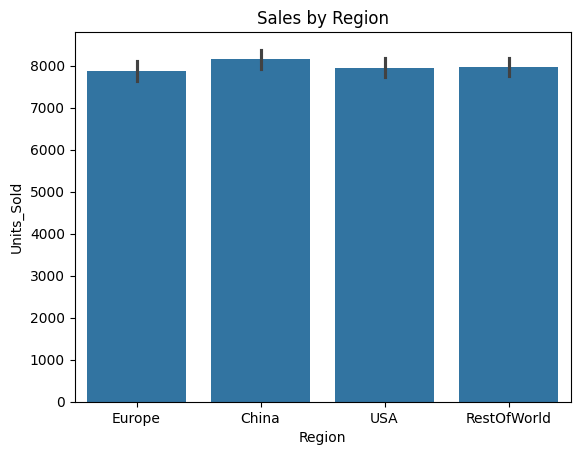

In [11]:
sns.barplot(x="Region", y="Units_Sold", data=df)
plt.title("Sales by Region")

Text(0.5, 1.0, 'BMW Sales Trend')

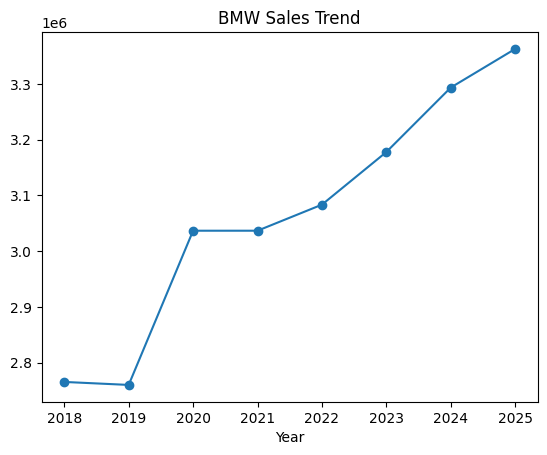

In [12]:
sales_trend = df.groupby("Year")["Units_Sold"].sum()

sales_trend.plot(kind="line", marker="o")
plt.title("BMW Sales Trend")

<Axes: ylabel='Model'>

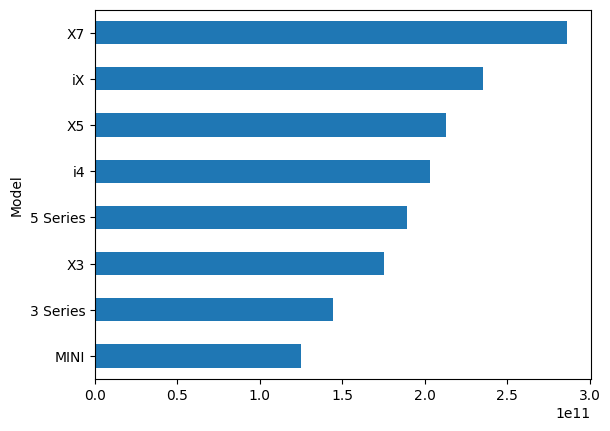

In [13]:
df.groupby("Model")["Revenue_EUR"].sum().sort_values().plot(kind="barh")

<Axes: >

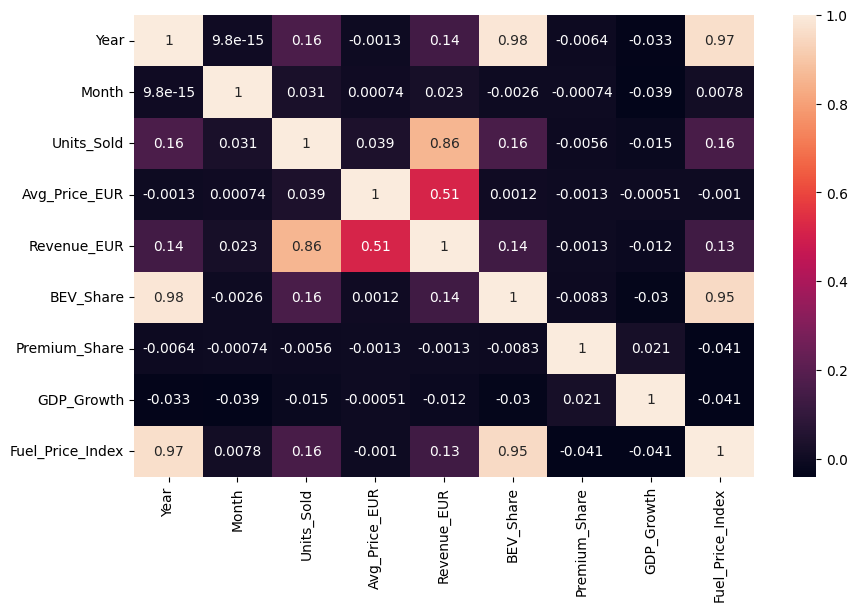

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)


In [15]:
df = pd.get_dummies(df, columns=["Region", "Model"], drop_first=True)

In [16]:
X = df.drop(["Units_Sold", "Date"], axis=1)
y = df["Units_Sold"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# **LinearRegression**

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

# **RandomForest**

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

# **Model Evaluation**

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 83.05796747967479
R2 Score: 0.9981021507011775


<Axes: >

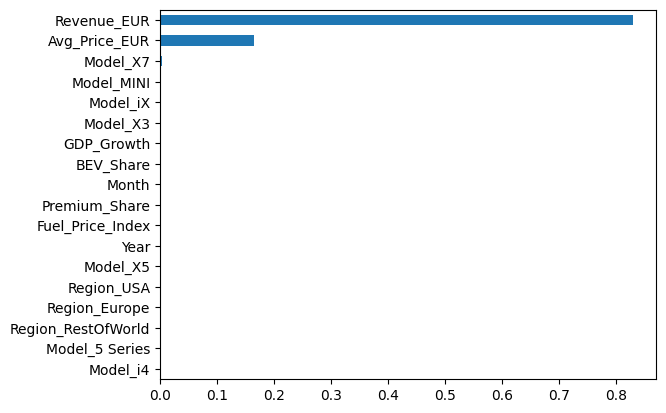

In [21]:
importance = rf.feature_importances_

feat = pd.Series(importance, index=X.columns)
feat.sort_values().plot(kind='barh')